# QC Modeling Benchmark

This notebook is a **general modeling and leakage-audit notebook** for spike-sorting QC datasets.

It is designed to answer the practical questions that matter before trusting a prototype:

- Is the dataset clean enough to model?
- Can we avoid obvious leakage?
- Does grouped recording holdout still perform well?
- Does performance collapse on paired, synth, or held-out sorters?
- Which features are actually driving the model?
- On average, how far are the predictions from `accuracy`, `fpos`, and `fmiss`?

## Modeling Principles

The notebook is intentionally conservative.

- Dataset names and dataset types are **not used as model features**.
- `sorter_name` is **not used as a model feature**.
- The primary benchmark is a **grouped recording holdout**, not a row-random split.
- Duplicate perfect matches for the same GT unit across different sorters are cleaned so
  the training data is less inflated by repeated perfect examples.
- A row-random split is still shown, but only as a **leakage reference**, not as the main claim.

In [38]:
import importlib
import subprocess
import sys

REQUIRED = ["lightgbm", "shap", "seaborn", "pyarrow", "scipy"]
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


In [40]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from qc_framework import (
    QCBenchmarkPipeline,
    QCDataCleaner,
    QCEvaluator,
    JointEvaluator,
    SHAPAnalyzer,
)
from qc_framework.features import FeatureSetBuilder

warnings.filterwarnings("ignore", message="X does not have valid feature names")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

# -----------------------------------------------------------------------
# CONFIG — set your paths here
# -----------------------------------------------------------------------
TRAIN_PARQUET_PATH = PROJECT_ROOT / "data" / "featuretrain.parquet"
TEST_PARQUET_PATH  = None  # set to a Path or leave None

# Optional: override the output directory (default: analysis/runs/<train_stem>/outputs)
OUTPUT_DIR = None
# -----------------------------------------------------------------------

assert TRAIN_PARQUET_PATH.exists(), f"Missing training parquet: {TRAIN_PARQUET_PATH}"
if TEST_PARQUET_PATH is not None:
    assert Path(TEST_PARQUET_PATH).exists(), f"Missing test parquet: {TEST_PARQUET_PATH}"

if OUTPUT_DIR is None:
    OUTPUT_DIR = PROJECT_ROOT / "analysis" / "runs" / TRAIN_PARQUET_PATH.stem.lower() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train :", TRAIN_PARQUET_PATH)
print("Test  :", TEST_PARQUET_PATH)
print("Output:", OUTPUT_DIR)

Train : /Users/paulruiz/Documents/Predicting_Good_Units/data/featuretrain.parquet
Test  : None
Output: /Users/paulruiz/Documents/Predicting_Good_Units/analysis/runs/featuretrain/outputs


## 1. Load and Clean

In [41]:
pipeline = QCBenchmarkPipeline(
    train_path=TRAIN_PARQUET_PATH,
    test_path=TEST_PARQUET_PATH,
    random_state=42,
    grouped_test_size=0.20,
    weighting_strategy="paired_3x",  # 3x weight for paired rows during training
)

train_clean, test_clean, clean_report = pipeline.load_and_clean()

print("Drop summary:")
display(clean_report["drop_summary"])

print("\nLeakage scan (dataset-type encoding):")
leakage_scan = clean_report["leakage_scan"]
display(leakage_scan[leakage_scan["action"] == "flag"])

Drop summary:


,rows_before,rows_after,rows_dropped,affected_gt_groups
0,33206,33193,13,11



Leakage scan (dataset-type encoding):


,feature,stat,p_value,effect_size,action
1,rec_noise_std_uv,20190.450,0.000000e+00,0.6083,flag
0,rec_noise_mean_uv,20185.391,0.000000e+00,0.6081,flag
5,rec_sampling_rate,9482.914,0.000000e+00,0.2857,flag
2,rec_duration_sec,5365.819,0.000000e+00,0.1616,flag
3,rec_n_channels,1421.676,4.095307e-311,0.0428,flag
4,rec_n_units,71.780,2.405478e-17,0.0021,flag


## 2. Feature Spaces

In [42]:
specs = pipeline.build_feature_specs(train_clean)

overview = pd.DataFrame([
    {
        "mode": s.mode,
        "exclude_soft": bool(s.soft_excluded_cols),
        "n_numeric": len(s.numeric_cols),
        "n_categorical": len(s.categorical_cols),
        "n_total": len(s.all_features),
    }
    for s in specs
])
display(overview)


,mode,exclude_soft,n_numeric,n_categorical,n_total
0,unit_only,False,165,0,165
1,unit_plus_recording,False,170,0,170


## 3. Split

In [43]:
grouped_train, grouped_test, row_random_train, row_random_test, split_report = pipeline.split(train_clean)

print("Grouped split:")
display(pd.DataFrame([split_report["grouped"]]))

if "dataset_type" in grouped_train.columns:
    coverage = pd.concat([
        grouped_train["dataset_type"].value_counts().rename("train_rows"),
        grouped_test["dataset_type"].value_counts().rename("test_rows"),
    ], axis=1).fillna(0).astype(int)
    display(coverage)


Grouped split:


,recording_overlap,train_rows,test_rows,train_recordings,test_recordings,train_dataset_types,test_dataset_types
0,[],24935,8258,72,19,"{'hybrid': 18050, 'paired': 6885}","{'hybrid': 6161, 'paired': 2097}"


,train_rows,test_rows
dataset_type,,
hybrid,18050,6161
paired,6885,2097


## 4. Baseline Models

Fits LightGBM, RandomForest, and Dummy across:
- row-random reference (unit_only)
- grouped recording (unit_only)
- grouped recording (unit_plus_recording)

In [44]:
#comment out to have normal fmiss
TARGETS = ["accuracy", "fpos", "fmiss_extended"]

results = pipeline.fit_baseline(
    grouped_train, grouped_test, row_random_train, row_random_test, specs, targets= TARGETS
)
results_df = pipeline.results_table(results)
display(results_df)


,target,split,feature_mode,model,n_train,n_test,mae,rmse,r2,bias
11,accuracy,grouped_recording,unit_only,lightgbm,24935,8258,0.037011,0.070017,0.966948,0.003883
10,accuracy,grouped_recording,unit_only,random_forest,24935,8258,0.032682,0.070979,0.966033,0.003013
9,accuracy,grouped_recording,unit_only,dummy,24935,8258,0.339343,0.385124,-0.000004,0.000746
17,fmiss_extended,grouped_recording,unit_only,lightgbm,24935,8258,0.036839,0.073724,0.965220,-0.004121
16,fmiss_extended,grouped_recording,unit_only,random_forest,24935,8258,0.032506,0.075838,0.963197,-0.002451
15,fmiss_extended,grouped_recording,unit_only,dummy,24935,8258,0.351863,0.395315,-0.000005,-0.000913
14,fpos,grouped_recording,unit_only,lightgbm,24935,8258,0.043138,0.101676,0.954458,-0.003627
13,fpos,grouped_recording,unit_only,random_forest,24935,8258,0.042259,0.106001,0.950501,-0.001614
12,fpos,grouped_recording,unit_only,dummy,24935,8258,0.466551,0.476457,-0.000047,0.003267
20,accuracy,grouped_recording,unit_plus_recording,lightgbm,24935,8258,0.035932,0.066922,0.969805,0.003114


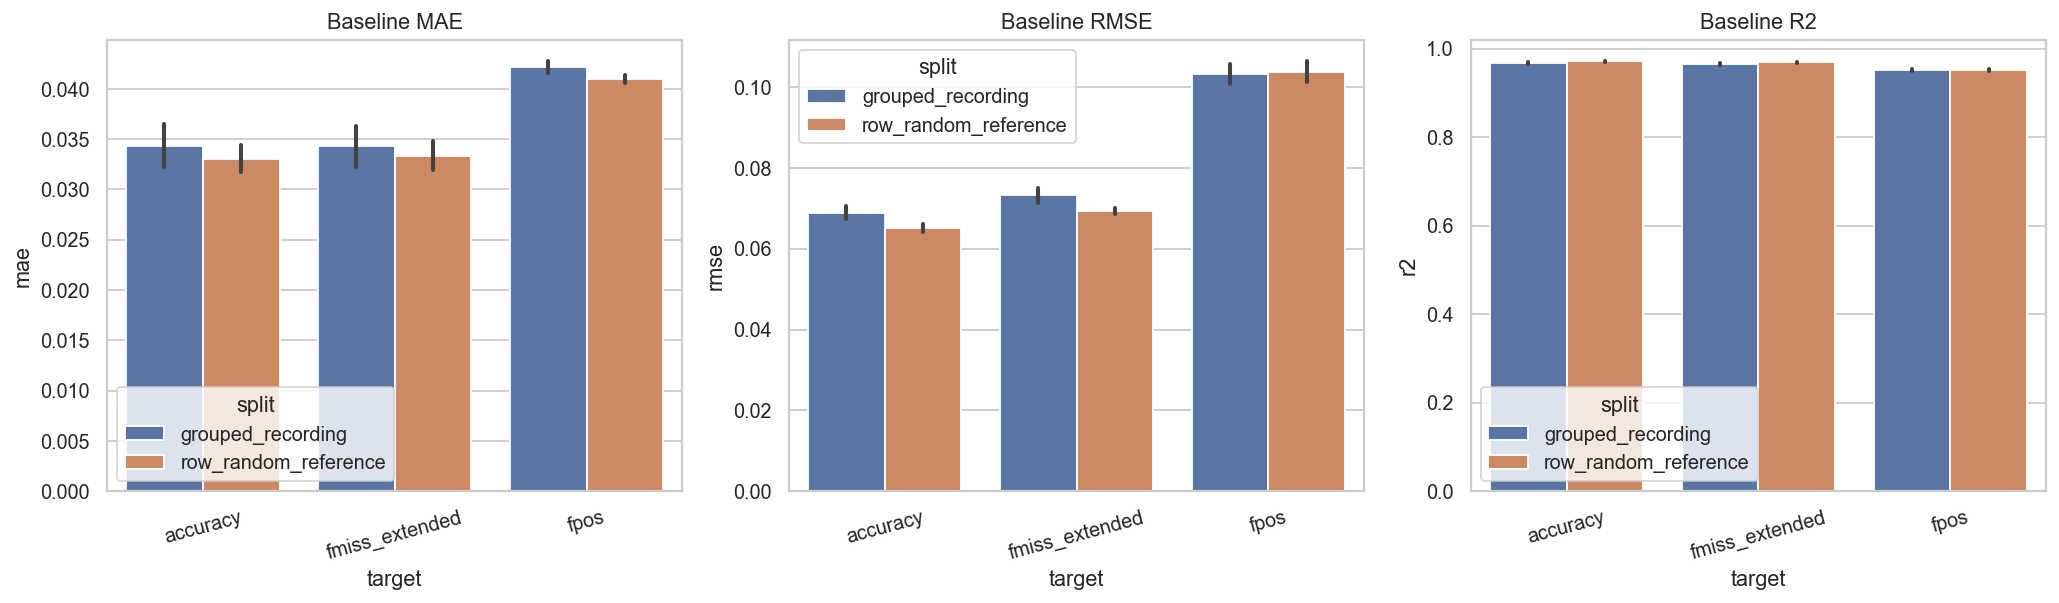

In [45]:
if not results_df.empty:
    plot_df = results_df[results_df["model"] != "dummy"].copy()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
        sns.barplot(data=plot_df, x="target", y=metric, hue="split", ax=ax)
        ax.set_title(f"Baseline {metric.upper()}")
        ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()


## 4b. Performance by Dataset Type

Same grouped/unit_only models evaluated separately on hybrid, paired, and synth subsets.
This reveals whether the aggregate metric is hiding collapse on any one domain.

,target,feature_mode,model,dataset_type,n,mae,rmse,r2
2,accuracy,unit_only,lightgbm,hybrid,6161,0.040347,0.065143,0.970276
3,accuracy,unit_only,lightgbm,paired,2097,0.027210,0.082691,0.315347
10,fmiss_extended,unit_only,lightgbm,hybrid,6161,0.039149,0.066607,0.970120
11,fmiss_extended,unit_only,lightgbm,paired,2097,0.030052,0.091484,0.294420
6,fpos,unit_only,lightgbm,hybrid,6161,0.048039,0.107817,0.935295
7,fpos,unit_only,lightgbm,paired,2097,0.028741,0.080987,0.506070
0,accuracy,unit_only,random_forest,hybrid,6161,0.035875,0.066215,0.969290
1,accuracy,unit_only,random_forest,paired,2097,0.023301,0.083417,0.303272
8,fmiss_extended,unit_only,random_forest,hybrid,6161,0.035775,0.070566,0.966463
9,fmiss_extended,unit_only,random_forest,paired,2097,0.022900,0.089549,0.323965


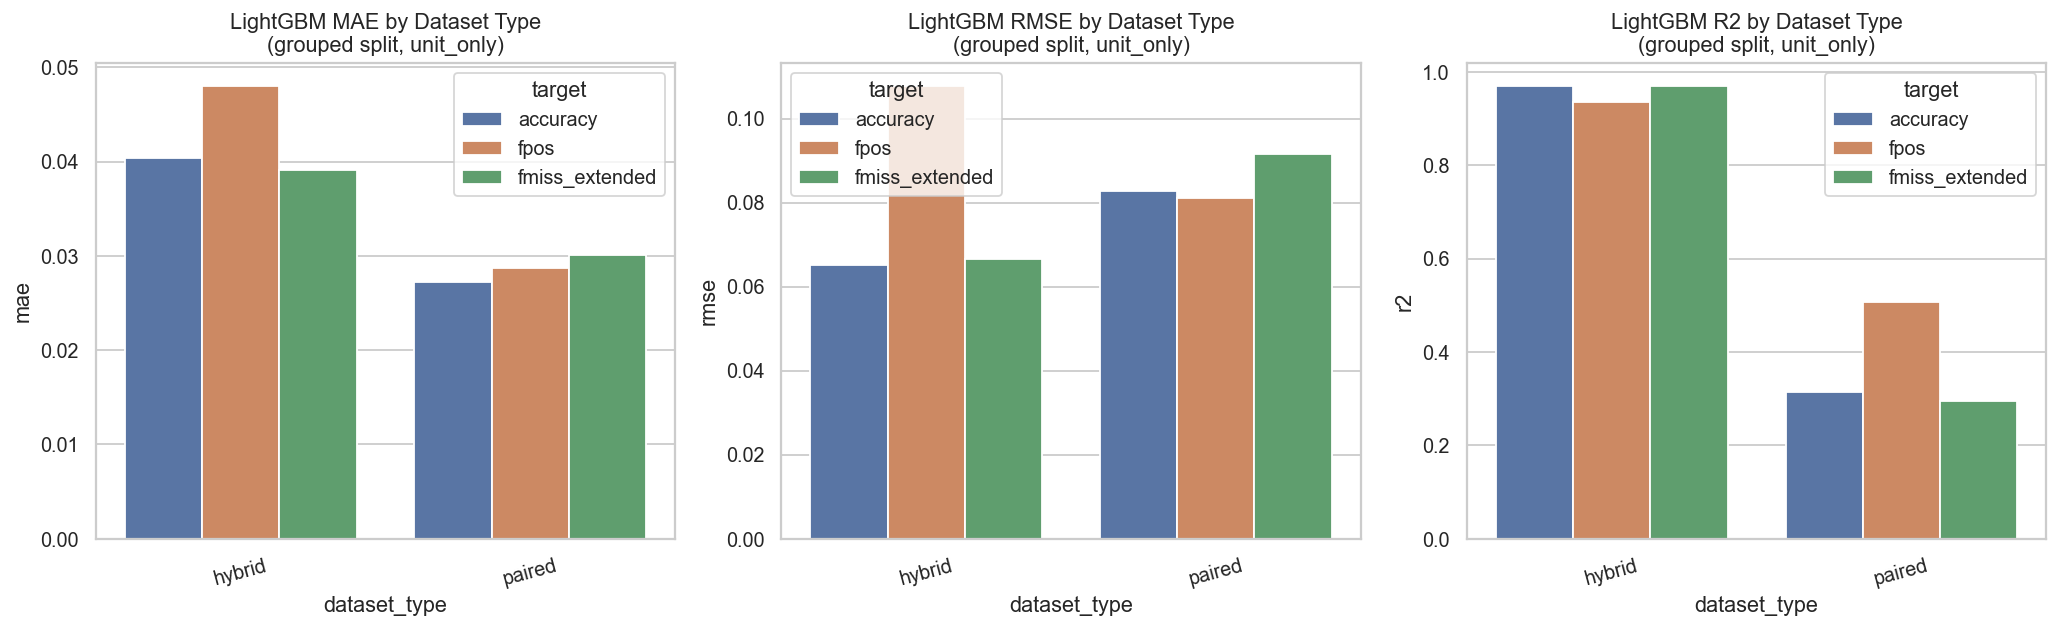

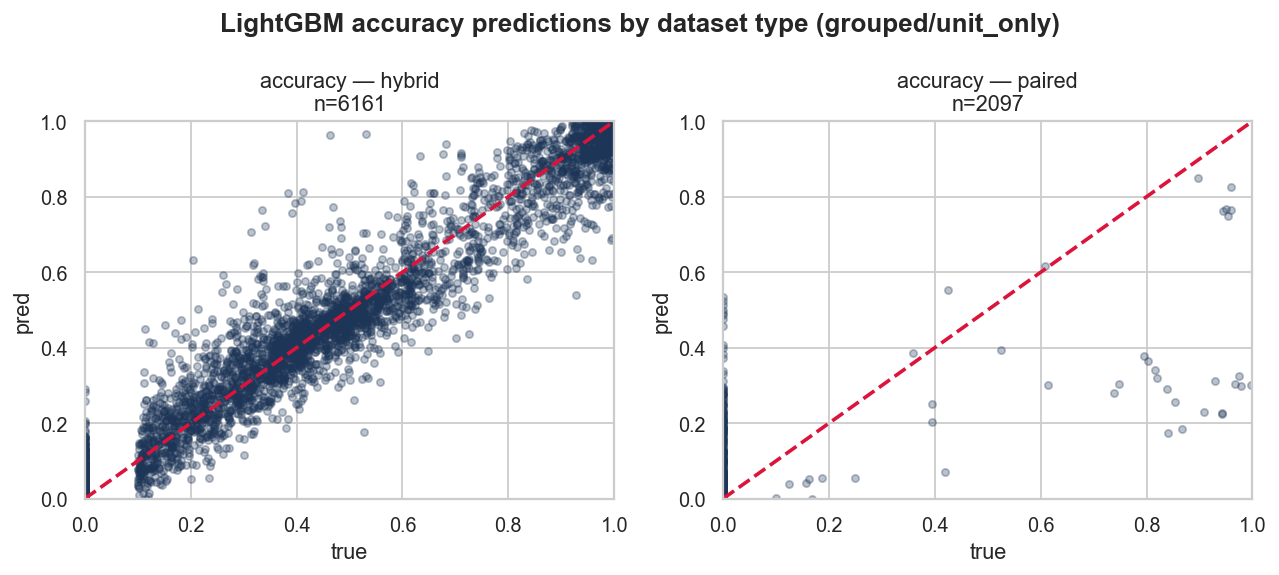

In [46]:
# Per-dataset-type performance breakdown (grouped/unit_only, trained on full grouped_train)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as _r2

breakdown_rows = []
for result in results:
    if result.split_name != "grouped_recording" or result.model_name not in ["lightgbm", "random_forest"]:
        continue
    for dtype, grp in result.predictions.groupby("dataset_type"):
        if len(grp) < 5:
            continue
        y_true = grp["true"].values
        y_pred = grp["pred"].values
        n_unique = len(np.unique(y_true))
        breakdown_rows.append({
            "target": result.target,
            "feature_mode": result.feature_mode,
            "model": result.model_name,
            "dataset_type": dtype,
            "n": int(len(grp)),
            "mae": float(mean_absolute_error(y_true, y_pred)),
            "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
            "r2": float(_r2(y_true, y_pred)) if n_unique > 1 else float("nan"),
        })

breakdown_df = pd.DataFrame(breakdown_rows)
display(
    breakdown_df[breakdown_df["feature_mode"] == "unit_only"]
    .sort_values(["model", "target", "dataset_type"])
)

# Bar plot — LightGBM unit_only
lgbm_bd = breakdown_df[
    (breakdown_df["model"] == "lightgbm") & (breakdown_df["feature_mode"] == "unit_only")
]
if not lgbm_bd.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
        sns.barplot(data=lgbm_bd, x="dataset_type", y=metric, hue="target", ax=ax)
        ax.set_title(f"LightGBM {metric.upper()} by Dataset Type\n(grouped split, unit_only)")
        ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

# Scatter per dataset type for accuracy/lightgbm
key = next(
    (r for r in results if r.target == "accuracy" and r.split_name == "grouped_recording"
     and r.feature_mode == "unit_only" and r.model_name == "lightgbm"), None
)
if key is not None:
    dtypes = sorted(key.predictions["dataset_type"].unique())
    fig, axes = plt.subplots(1, len(dtypes), figsize=(5 * len(dtypes), 4.5))
    if len(dtypes) == 1:
        axes = [axes]
    for ax, dtype in zip(axes, dtypes):
        grp = key.predictions[key.predictions["dataset_type"] == dtype]
        ax.scatter(grp["true"], grp["pred"], s=16, alpha=0.3, color="#1d3557")
        ax.plot([0, 1], [0, 1], color="crimson", lw=2, ls="--")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(f"accuracy — {dtype}\nn={len(grp)}")
        ax.set_xlabel("true"); ax.set_ylabel("pred")
    fig.suptitle("LightGBM accuracy predictions by dataset type (grouped/unit_only)", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5. Joint Target Distance

Average absolute error across `accuracy`, `fpos`, and `fmiss` per row.

In [47]:
joint = pipeline.joint_metrics(results)
display(joint)


""


## 6. Dataset-Type Transfer

,target,split,feature_mode,model,n_train,n_test,mae,rmse,r2,bias
1,accuracy,holdout_dataset_type:hybrid,unit_only,random_forest,8982,24211,0.461479,0.587534,-1.434312,-0.455320
0,accuracy,holdout_dataset_type:hybrid,unit_only,dummy,8982,24211,0.471117,0.597916,-1.521110,-0.464435
2,accuracy,holdout_dataset_type:hybrid,unit_only,lightgbm,8982,24211,0.471151,0.600265,-1.540955,-0.469224
7,fmiss,holdout_dataset_type:hybrid,unit_only,random_forest,207,18440,0.253324,0.280717,0.143631,-0.023239
8,fmiss,holdout_dataset_type:hybrid,unit_only,lightgbm,207,18440,0.252014,0.292570,0.069786,0.016269
6,fmiss,holdout_dataset_type:hybrid,unit_only,dummy,207,18440,0.281974,0.309127,-0.038478,-0.059504
4,fpos,holdout_dataset_type:hybrid,unit_only,random_forest,8982,24211,0.697664,0.805756,-2.716046,0.691150
3,fpos,holdout_dataset_type:hybrid,unit_only,dummy,8982,24211,0.704839,0.812090,-2.774695,0.696259
5,fpos,holdout_dataset_type:hybrid,unit_only,lightgbm,8982,24211,0.702740,0.813574,-2.788506,0.699560
11,accuracy,holdout_dataset_type:paired,unit_only,lightgbm,24211,8982,0.304743,0.373631,-12.416947,0.294350


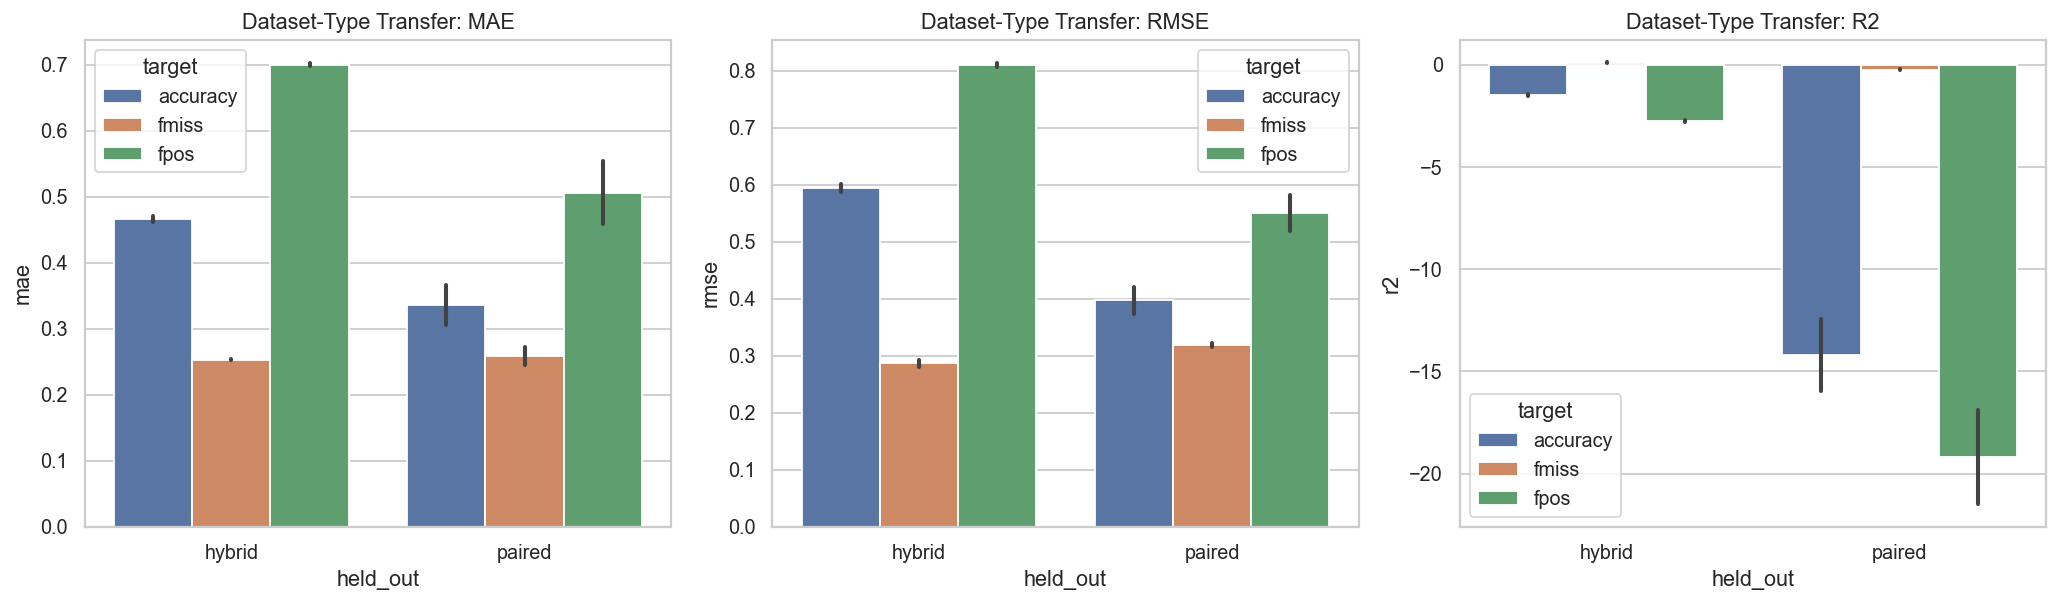

In [48]:
transfer = pipeline.dataset_type_transfer(train_clean, specs)
display(transfer)

if not transfer.empty:
    transfer_plot = transfer[transfer["model"] != "dummy"].copy()
    transfer_plot["held_out"] = transfer_plot["split"].str.split(":").str[-1]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
        sns.barplot(data=transfer_plot, x="held_out", y=metric, hue="target", ax=ax)
        ax.set_title(f"Dataset-Type Transfer: {metric.upper()}")
    plt.tight_layout()
    plt.show()


## 7. Sorter Transfer

,target,split,feature_mode,model,n_train,n_test,mae,rmse,r2,bias
6,accuracy,holdout_sorter:HerdingSpikes2,unit_only,lightgbm,28168,5025,0.053551,0.098575,0.901808,0.032344
7,accuracy,holdout_sorter:HerdingSpikes2,unit_only,random_forest,28168,5025,0.064081,0.110461,0.876700,0.039389
10,fmiss,holdout_sorter:HerdingSpikes2,unit_only,lightgbm,16290,2357,0.086025,0.130729,0.776390,-0.052412
11,fmiss,holdout_sorter:HerdingSpikes2,unit_only,random_forest,16290,2357,0.094786,0.146514,0.719129,-0.051245
8,fpos,holdout_sorter:HerdingSpikes2,unit_only,lightgbm,28168,5025,0.073703,0.150113,0.884221,-0.042079
9,fpos,holdout_sorter:HerdingSpikes2,unit_only,random_forest,28168,5025,0.093084,0.164903,0.860283,-0.052567
36,accuracy,holdout_sorter:IronClust,unit_only,lightgbm,30474,2719,0.049708,0.090565,0.953629,-0.021277
37,accuracy,holdout_sorter:IronClust,unit_only,random_forest,30474,2719,0.053982,0.112744,0.928135,-0.027752
40,fmiss,holdout_sorter:IronClust,unit_only,lightgbm,16761,1886,0.032634,0.052903,0.948828,0.011791
41,fmiss,holdout_sorter:IronClust,unit_only,random_forest,16761,1886,0.036071,0.062933,0.927585,0.022990


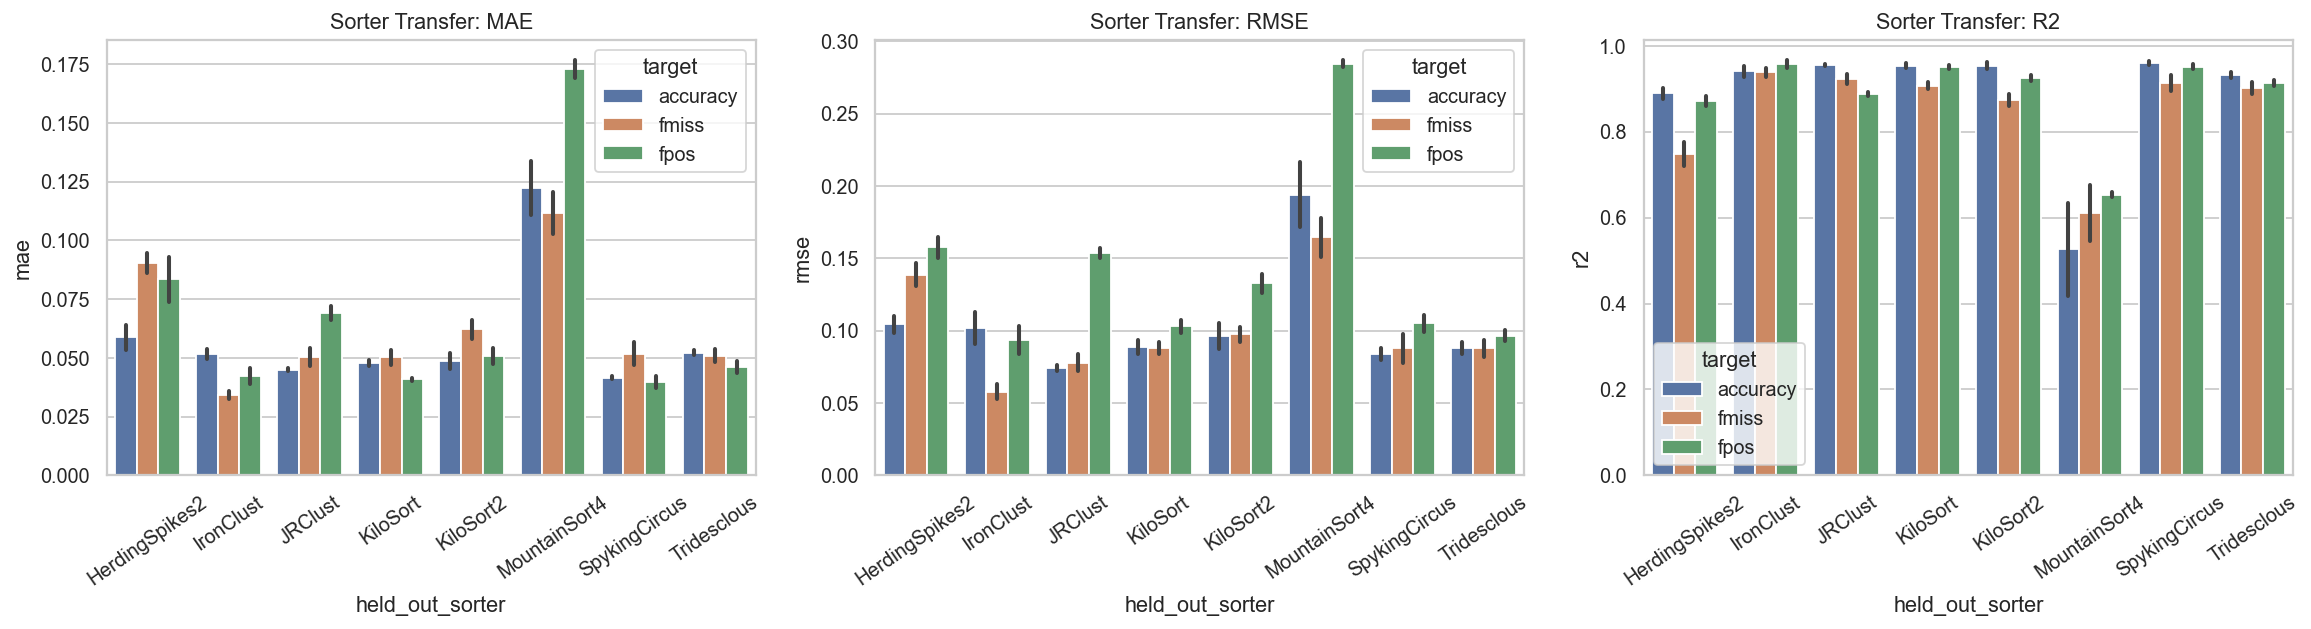

In [49]:
sorter_transfer = pipeline.sorter_transfer(train_clean, specs)
display(sorter_transfer)

if not sorter_transfer.empty:
    st_plot = sorter_transfer.copy()
    st_plot["held_out_sorter"] = st_plot["split"].str.split(":").str[-1]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
        sns.barplot(data=st_plot, x="held_out_sorter", y=metric, hue="target", ax=ax)
        ax.tick_params(axis="x", rotation=35)
        ax.set_title(f"Sorter Transfer: {metric.upper()}")
    plt.tight_layout()
    plt.show()


## 8. SHAP Feature Analysis


Top SHAP features for accuracy:


,feature,mean_abs_shap,family,rank
0,num__si_amplitude_cv_median,0.103000,spikeinterface,1
1,num__si_firing_rate_hz,0.052616,spikeinterface,2
2,num__amp_std,0.051372,other,3
3,num__isi_cv,0.035782,other,4
4,num__presence_ratio,0.033885,other,5
5,num__wf_bin_18,0.027421,waveform_bins,6
6,num__isi_mean_ms,0.021284,other,7
7,num__wf_bin_28,0.017763,waveform_bins,8
8,num__amp_bin_cv_std,0.016915,other,9
9,num__isi_violation_rate,0.013875,other,10


,family,mean_abs_shap
0,other,0.262041
1,spikeinterface,0.206896
2,waveform_bins,0.073250
3,cosine,0.037207
4,waveform,0.034950
5,acg,0.031188


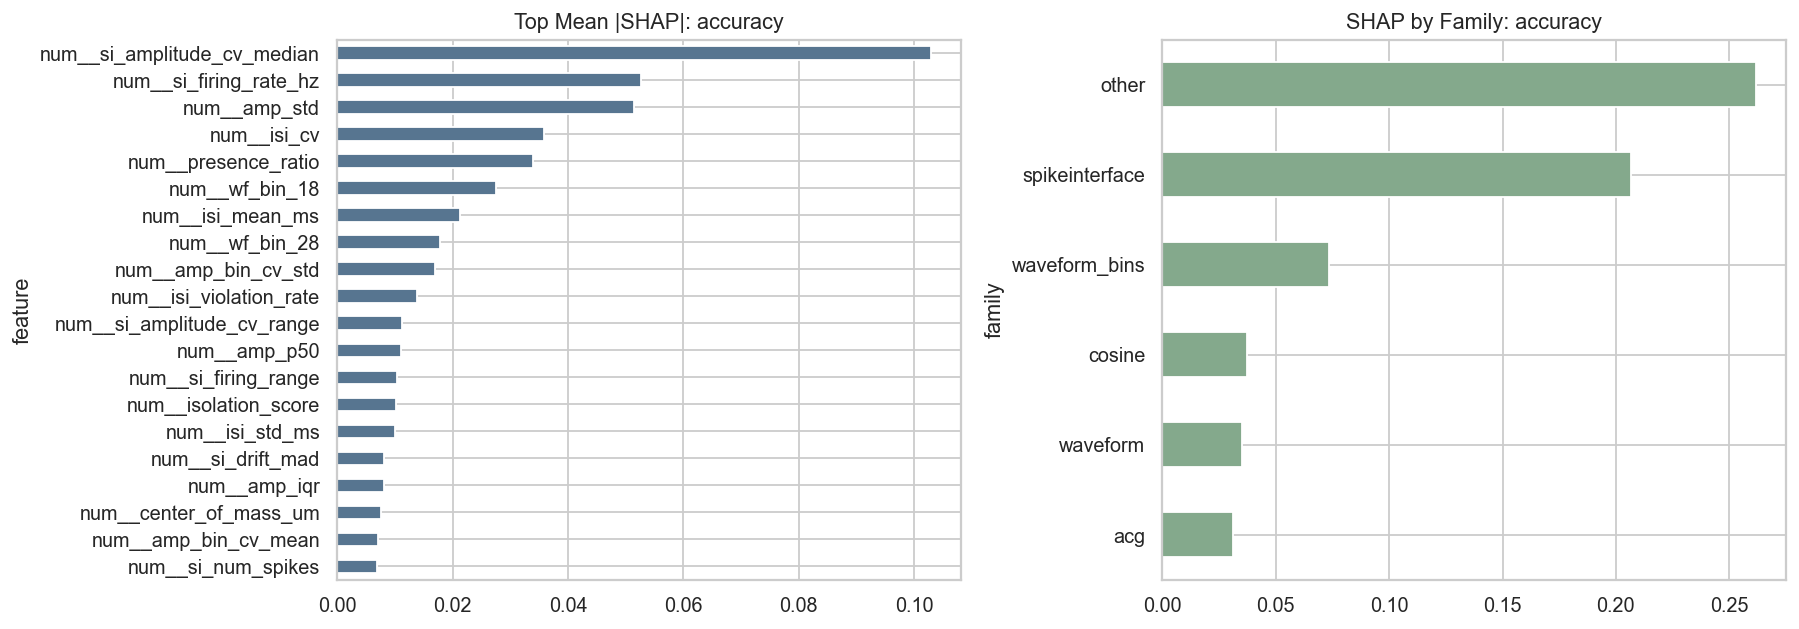


Top SHAP features for fpos:


,feature,mean_abs_shap,family,rank
0,num__amp_std,0.155560,other,1
1,num__si_firing_rate_hz,0.090020,spikeinterface,2
2,num__isi_mean_ms,0.042858,other,3
3,num__wf_bin_18,0.037136,waveform_bins,4
4,num__amp_p50,0.034365,other,5
5,num__amp_bin_cv_mean,0.027415,other,6
6,num__amp_iqr,0.018258,other,7
7,num__amp_p5,0.013508,other,8
8,num__presence_ratio,0.013377,other,9
9,num__isi_violation_rate,0.013337,other,10


,family,mean_abs_shap
0,other,0.402617
1,spikeinterface,0.125535
2,waveform_bins,0.072052
3,waveform,0.048116
4,acg,0.025946
5,cosine,0.021478


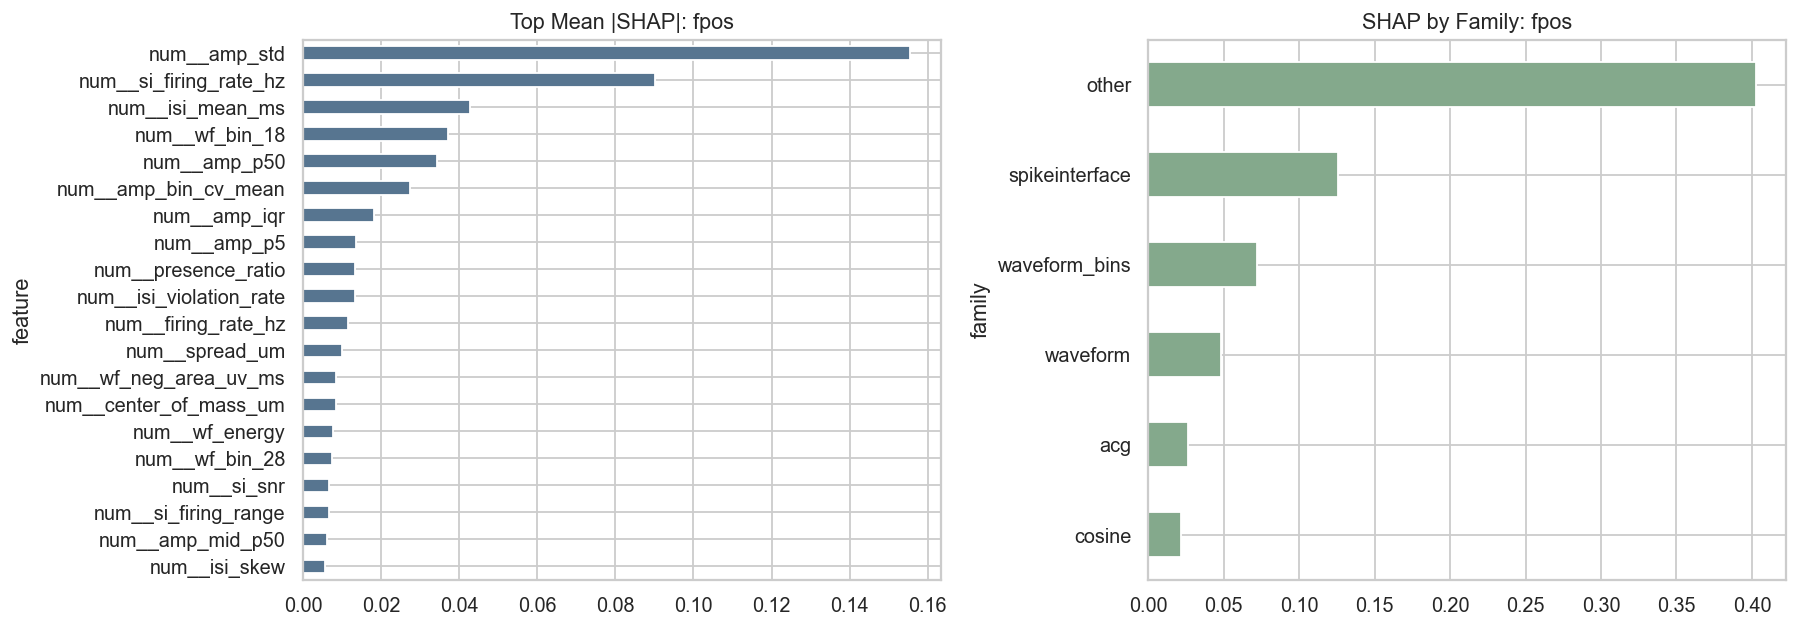

In [50]:
shap_results = pipeline.shap_analysis(results, grouped_train, grouped_test, specs)

for target, shap_df in shap_results.items():
    print(f"\nTop SHAP features for {target}:")
    display(shap_df.head(20))

    from qc_framework.evaluation import SHAPAnalyzer
    family_df = SHAPAnalyzer.family_summary(shap_df)
    display(family_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    shap_df.head(20).set_index("feature")["mean_abs_shap"].sort_values().plot(
        kind="barh", ax=axes[0], color="#577590"
    )
    axes[0].set_title(f"Top Mean |SHAP|: {target}")

    family_df.set_index("family")["mean_abs_shap"].sort_values().plot(
        kind="barh", ax=axes[1], color="#84a98c"
    )
    axes[1].set_title(f"SHAP by Family: {target}")
    plt.tight_layout()
    plt.show()


## 9. fpos vs fmiss Correlation Check

In [51]:
# Find grouped/unit_only lightgbm predictions for fpos and fmiss
fpos_result = next(
    (r for r in results if r.target == "fpos" and r.split_name == "grouped_recording"
     and r.feature_mode == "unit_only" and r.model_name == "lightgbm"), None
)
fmiss_result = next(
    (r for r in results if r.target == "fmiss" and r.split_name == "grouped_recording"
     and r.feature_mode == "unit_only" and r.model_name == "lightgbm"), None
)

if fpos_result and fmiss_result:
    merged = fpos_result.predictions.rename(
        columns={"true": "true_fpos", "pred": "pred_fpos"}
    ).merge(
        fmiss_result.predictions[["row_uid", "true", "pred"]].rename(
            columns={"true": "true_fmiss", "pred": "pred_fmiss"}
        ),
        on="row_uid", how="inner",
    )
    sample = merged.sample(min(len(merged), 1200), random_state=42)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(sample["true_fpos"], sample["true_fmiss"], s=14, alpha=0.25, color="#1d3557")
    axes[0].set_title("True fpos vs True fmiss")
    axes[0].set_xlabel("true fpos"); axes[0].set_ylabel("true fmiss")
    axes[1].scatter(sample["pred_fpos"], sample["pred_fmiss"], s=14, alpha=0.25, color="#e63946")
    axes[1].set_title("Predicted fpos vs Predicted fmiss")
    axes[1].set_xlabel("pred fpos"); axes[1].set_ylabel("pred fmiss")
    for ax in axes:
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    print({"true_corr": float(sample["true_fpos"].corr(sample["true_fmiss"])),
           "pred_corr": float(sample["pred_fpos"].corr(sample["pred_fmiss"]))})


## 10. Save Artifacts

In [52]:
import json as _json

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, df in [
    ("baseline_results", results_df),
    ("joint_target_distance_summary", joint),
    ("dataset_type_transfer_results", transfer),
    ("sorter_transfer_results", sorter_transfer),
]:
    if df is not None and not df.empty:
        df.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

if shap_results:
    shap_payload = {
        target: sdf.head(25).set_index("feature")["mean_abs_shap"].to_dict()
        for target, sdf in shap_results.items()
        if not sdf.empty
    }
    (OUTPUT_DIR / "shap_top_features.json").write_text(
        _json.dumps(shap_payload, indent=2), encoding="utf-8"
    )

leakage_scan = clean_report.get("leakage_scan")
if leakage_scan is not None and not leakage_scan.empty:
    leakage_scan.to_csv(OUTPUT_DIR / "leakage_scan.csv", index=False)

print("Saved to:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Saved to: /Users/paulruiz/Documents/Predicting_Good_Units/analysis/runs/featuretrain/outputs
 - baseline_results.csv
 - dataset_type_transfer_results.csv
 - featuretrain_feature_summary.csv
 - leakage_scan.csv
 - shap_top_features.json
 - sorter_transfer_results.csv
